In [1]:
from pycocotools.coco import COCO


coco = COCO("data/coco_tank_photos/result.json")
coco2 = COCO("data/coco_tank_photos2/result.json")
img_ids = coco.getImgIds()


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [2]:
import numpy as np
import tensorflow as tf
from keras.utils import img_to_array, load_img

def load_image(data : COCO, img_id, target_size=(512,512), num_od_ds=""):
    img_dir = f"data/coco_tank_photos{num_od_ds}/" + data.loadImgs(img_id)[0]["file_name"].replace("/", "/")
    img = img_to_array(load_img(path=img_dir, target_size=target_size)) / 255.

    orig_sizes = (data.loadImgs(img_id)[0]["width"], data.loadImgs(img_id)[0]["height"])

    boxes = []
    for i in range(len(data.loadAnns(data.getAnnIds(img_id)))):
        x, y, w, h = data.loadAnns(data.getAnnIds(img_id))[i]["bbox"]
        x1 = x / orig_sizes[0]
        w1 = w / orig_sizes[0]
        y1 = y / orig_sizes[1]
        h1 = h / orig_sizes[1]


        boxes.append([x1, y1, w1, h1])

    return img, np.array(boxes, np.float32)


2026-01-12 21:50:12.752892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768243812.772176   21058 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768243812.778407   21058 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768243812.794408   21058 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768243812.794428   21058 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768243812.794430   21058 computation_placer.cc:177] computation placer alr

In [3]:
def prepare_labels(bboxes, img_size=(512,512), strides=16):
    W = img_size[0] // strides
    H = img_size[1] // strides

    heatmap = np.zeros((H, W, 1), dtype=np.float32)
    bboxmap = np.zeros((H, W, 4), dtype=np.float32)

    for x, y, w, h in bboxes: 
        cx = x + w / 2
        cy = y + h / 2

        cx_s = cx / strides
        cy_s = cy / strides

        ix = int(cx_s)
        iy = int(cy_s)

        if ix < 0 or ix >= W or iy < 0 or iy >= H:
            continue

        heatmap[iy, ix, 0] = 1.0
        bboxmap[iy, ix] = [
            cx_s - ix,
            cy_s - iy,
            w / strides,
            h / strides
        ]

    return heatmap, bboxmap

In [4]:
num_samples = len(coco.imgs) + len(coco2.imgs) - 47

In [5]:
images_ds = np.zeros((num_samples, 512, 512, 3), dtype="float32")
labels_ds = np.zeros((num_samples, 32, 32, 5), dtype="float32")
for i in range(num_samples):
    try:
        image, boxes = load_image(coco, i)
    except:
        image, boxes = load_image(coco2, i - len(coco.imgs), num_od_ds="2")
    heatmap, bboxmap = prepare_labels(boxes)
    labels_ds[i] = np.concatenate((bboxmap, heatmap), axis=2)
    images_ds[i] = image

In [6]:
len(images_ds)

572

In [7]:
import matplotlib.pyplot as plt

def show_image(image, boxes=np.zeros((15, 5), dtype=np.float32), original_size=(512, 512), ignore_objectnesses=False, alpha=0.5, output=None, color="red"):
    fig, ax = plt.subplots()
    ax.imshow(image)


    for i in range(len(boxes)):
        if ignore_objectnesses or boxes[i][4] >= alpha:
            rect = patches.Rectangle((boxes[i][0] * original_size[0], boxes[i][1]* original_size[1]), boxes[i][2]* original_size[0], boxes[i][3]* original_size[1], fill=False, color=color)
            ax.add_patch(rect)
            continue
    
    if output:
        plt.savefig(output, dpi=300)
        plt.close()
    else:
        plt.show()

In [8]:
from keras import layers

class FCOSHead(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv1_c = layers.Conv2D(256, 1)
        self.conv2_c = layers.Conv2D(256, 1)
        self.conv3_c = layers.Conv2D(256, 1)
        self.conv4_c = layers.Conv2D(256, 1)
        self.conv5_c = layers.Conv2D(1, 1)

        self.conv1_b = layers.Conv2D(256, 1)
        self.conv2_b = layers.Conv2D(256, 1)
        self.conv3_b = layers.Conv2D(256, 1)
        self.conv4_b = layers.Conv2D(256, 1)
        self.conv5_b = layers.Conv2D(4, 1)
        
    def call(self, inputs):
        x = self.conv1_c(inputs)
        x = self.conv2_c(x)
        x = self.conv3_c(x)
        x = self.conv4_c(x)
        x = self.conv5_c(x)

        y = self.conv1_b(inputs)
        y = self.conv2_b(y)
        y = self.conv3_b(y)
        y = self.conv4_b(y)
        y = self.conv5_b(y)

        return x, y

In [9]:
import keras
import mlflow
import mlflow.tensorflow
from mlflow.tensorflow import MLflowCallback

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.tensorflow.autolog(disable=True)


epoches = 100
batch_size = 16

keras.mixed_precision.set_global_policy('mixed_float16')


inputs = keras.Input(shape=(512,512,3), name="image")

x = layers.Conv2D(32, 5, padding="same", use_bias=False)(inputs)

C = []

for i, size in enumerate([32, 64, 128, 256]):
    residual = x

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    residual = layers.Conv2D(
        size, 1, strides=2, padding="same", use_bias=False
    )(residual)

    x = layers.add([x, residual], name=f"C{2+i}")

    C.append(x)

P= [C[-1]]
for i in range(3):
    x = layers.UpSampling2D()(P[-1])
    residual = layers.Conv2D(256, 1)(C[-2-i])
    x = layers.add([x, residual], name=f"P{4-i}")
    P.append(x)


outputs = []

for p in P:
    x = FCOSHead()(p)
    outputs.append(x)


model = keras.Model(inputs=inputs, outputs=outputs, name="LuchScanV1")
model.summary()

I0000 00:00:1768243824.276230   21058 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9232 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:24:00.0, compute capability: 8.6


Model: "LuchScanV1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 512, 512,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      2,400 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 512, 512,  │      1,312 │ activation[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 512, 512,  │      1,312 │ activation_1[0][… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      1,024 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ C2 (Add)            │ (None, 256, 256,  │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ C2[0][0]          │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 256, 256,  │      2,336 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 256, 256,  │      4,672 │ activation_3[0][

 Total params: 2,355,668 (8.99 MB)

 Trainable params: 2,354,196 (8.98 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
class FeatureMapDecoder(layers.Layer):
    def __init__(self, score_threshold=0.05, **kwargs):
        super().__init__(**kwargs)
        self.score_threshold = score_threshold

    def call(self, inputs):
        [heatmap, bboxmap] = inputs
        stride = 512.0 / heatmap.shape[1]
        H, W = heatmap.shape[1], heatmap.shape[2]

        ys = tf.range(H, dtype=tf.float32)
        xs = tf.range(W, dtype=tf.float32)
        yy, xx = tf.meshgrid(ys, xs, indexing="ij")

        cx = (xx + 0.5) * stride
        cy = (yy + 0.5) * stride

        l, t, r, b = tf.split(bboxmap, 4, axis=-1)

        x1 = cx[..., None] - l
        y1 = cy[..., None] - t
        x2 = cx[..., None] + r
        y2 = cy[..., None] + b

        boxes = tf.concat([x1, y1, x2, y2], axis=-1)

        h_img, w_img = 512, 512
        boxes = tf.stack([
            tf.clip_by_value(boxes[..., 0], 0, w_img),
            tf.clip_by_value(boxes[..., 1], 0, h_img),
            tf.clip_by_value(boxes[..., 2], 0, w_img),
            tf.clip_by_value(boxes[..., 3], 0, h_img),], axis=-1
        )

        heatmap_probs = tf.sigmoid(heatmap)
        scores = tf.reduce_max(heatmap_probs, axis=-1)
        keep = scores > self.score_threshold
        boxes = tf.boolean_mask(boxes, keep)
        scores = tf.boolean_mask(scores, keep)

        return boxes, scores
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "score_threshold": self.score_threshold
        })
        return config

In [ ]:
def bbox_to_fcos(bboxes=np.zeros((5, 4), dtype=np.float32)):
    fcos_1 = np.array([np.zeros((32, 32, 4), dtype=np.float32), np.zeros((32, 32, 1), dtype=np.float32)])
    fcos_2 = np.array([np.zeros((64, 64, 4), dtype=np.float32), np.zeros((64, 64, 1), dtype=np.float32)])
    fcos_3 = np.array([np.zeros((128, 128, 4), dtype=np.float32), np.zeros((128, 128, 1), dtype=np.float32)])
    fcos_4 = np.array([np.zeros((256, 256, 4), dtype=np.float32), np.zeros((256, 256, 1), dtype=np.float32)])

    for bbox in bboxes:
        size = max(bbox[2:])


In [10]:
def bbox_converter(box):
    cx, cy, w, h = tf.split(box, 4, axis=-1)
    x = cx - w * 0.5
    y = cy - h * 0.5
    return tf.concat([x, y, w, h], axis=-1)

In [11]:
def iou_loss(y_true, y_pred):
    y_pred_conf = y_pred[..., 4:]
    y_true_conf = y_true[..., 4:]
    y_true = y_true[..., :4]
    y_pred = y_pred[..., :4]

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_conf = tf.cast(y_pred_conf, tf.float32)
    y_true_conf = tf.cast(y_true_conf, tf.float32)

    mask = tf.squeeze(y_true_conf, axis=-1)
    mask = tf.cast(mask > 0.5, tf.float32)
    mask_exp = tf.expand_dims(mask, axis=-1)

    y_true = bbox_converter(y_true) * mask_exp
    y_pred = bbox_converter(y_pred) * mask_exp

    w_area = tf.maximum(0., tf.minimum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2]) - tf.maximum(y_true[..., 0], y_pred[..., 0]))
    h_area = tf.maximum(0., tf.minimum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3]) - tf.maximum(y_true[..., 1], y_pred[..., 1]))
    s_area = w_area * h_area

    s_true = y_true[..., 2] * y_true[..., 3]
    s_pred = y_pred[..., 2] * y_pred[..., 3]

    union = s_true + s_pred - s_area
    iou = (s_area + 1e-7) / (union + 1e-7)

    x1c = tf.minimum(y_true[..., 0], y_pred[..., 0])
    y1c = tf.minimum(y_true[..., 1], y_pred[..., 1])
    x2c = tf.maximum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2])
    y2c = tf.maximum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3])

    #c = (x2c - x1c) * (y2c - y1c)

    #giou = iou - (c - union) / (c + 1e-7)

    conf = keras.losses.binary_crossentropy(y_true_conf, y_pred_conf)

    b_pred_x = y_pred[..., 0] + y_pred[..., 2] / 2.
    b_pred_y = y_pred[..., 1] + y_pred[..., 3] / 2.

    b_true_x = y_true[..., 0] + y_true[..., 2] / 2.
    b_true_y = y_true[..., 1] + y_true[..., 3] / 2.

    p2 = tf.square(b_pred_x - b_true_x) + tf.square(b_pred_y - b_true_y)

    c2 = tf.square(x2c - x1c) + tf.square(y2c - y1c)

    v = 4 / tf.square(3.141592) * tf.square(tf.atan(tf.math.divide_no_nan(y_true[..., 2], y_true[..., 3])) - tf.atan(tf.math.divide_no_nan(y_pred[..., 2], y_pred[..., 3])))

    a = v / ((1 - iou) + v + 1e-7)

    ciou = tf.math.divide_no_nan(p2, c2) + a*v

    ciou_loss = 1.0 - iou + ciou
    ciou_loss = tf.expand_dims(ciou_loss, axis=-1)
    ciou_loss = ciou_loss * mask_exp

    sum_mask = tf.reduce_sum(mask) + 1e-7

    ciou_loss = tf.reduce_sum(ciou_loss) / sum_mask


    return ciou_loss + tf.reduce_mean(0.25 * conf)

In [12]:
def iou_metric(y_true, y_pred):
    y_pred_conf = y_pred[..., 4:]
    y_true_conf = y_true[..., 4:]
    y_true = y_true[..., :4]
    y_pred = y_pred[..., :4]

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_conf = tf.cast(y_pred_conf, tf.float32)
    y_true_conf = tf.cast(y_true_conf, tf.float32)

    mask = tf.squeeze(y_true_conf, axis=-1)
    mask = tf.cast(mask > 0.5, tf.float32)
    mask_exp = tf.expand_dims(mask, axis=-1)

    w_area = tf.maximum(0., tf.minimum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2]) - tf.maximum(y_true[..., 0], y_pred[..., 0]))
    h_area = tf.maximum(0., tf.minimum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3]) - tf.maximum(y_true[..., 1], y_pred[..., 1]))
    s_area = w_area * h_area

    s_true = y_true[..., 2] * y_true[..., 3]
    s_pred = y_pred[..., 2] * y_pred[..., 3]

    union = s_true + s_pred - s_area
    iou = (s_area + 1e-7) / (union + 1e-7)
    iou = tf.expand_dims(iou, axis=-1)
    iou = iou * mask_exp

    sum_mask = tf.reduce_sum(mask) + 1e-7

    iou = tf.reduce_sum(iou) / sum_mask

    return iou

def giou_metric(y_true, y_pred):
    y_pred_conf = y_pred[..., 4:]
    y_true_conf = y_true[..., 4:]
    y_true = y_true[..., :4]
    y_pred = y_pred[..., :4]

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_conf = tf.cast(y_pred_conf, tf.float32)
    y_true_conf = tf.cast(y_true_conf, tf.float32)

    mask = tf.squeeze(y_true_conf, axis=-1)
    mask = tf.cast(mask > 0.5, tf.float32)
    mask_exp = tf.expand_dims(mask, axis=-1)

    y_true = bbox_converter(y_true) * mask_exp
    y_pred = bbox_converter(y_pred) * mask_exp

    w_area = tf.maximum(0., tf.minimum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2]) - tf.maximum(y_true[..., 0], y_pred[..., 0]))
    h_area = tf.maximum(0., tf.minimum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3]) - tf.maximum(y_true[..., 1], y_pred[..., 1]))
    s_area = w_area * h_area

    s_true = y_true[..., 2] * y_true[..., 3]
    s_pred = y_pred[..., 2] * y_pred[..., 3]

    union = s_true + s_pred - s_area
    iou = (s_area + 1e-7) / (union + 1e-7)

    x1c = tf.minimum(y_true[..., 0], y_pred[..., 0])
    y1c = tf.minimum(y_true[..., 1], y_pred[..., 1])
    x2c = tf.maximum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2])
    y2c = tf.maximum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3])

    c = (x2c - x1c) * (y2c - y1c)

    giou = iou - (c - union) / (c + 1e-7)
    giou = tf.expand_dims(giou, axis=-1)
    giou = giou * mask_exp

    sum_mask = tf.reduce_sum(mask) + 1e-7

    giou = tf.reduce_sum(giou) / sum_mask

    return giou

def mean_binary_crossentropy_metric(y_true, y_pred):
    y_true_obj = y_true[..., 4]
    y_pred_obj = y_pred[..., 4]

    y_true_obj = tf.cast(y_true_obj, tf.float32) + 1e-6
    y_pred_obj = tf.cast(y_pred_obj, tf.float32) + 1e-6

    conf = keras.losses.binary_crossentropy(y_true_obj, y_pred_obj)
    conf = tf.reduce_mean(conf)

    return conf

def ciou_metric(y_true, y_pred):
    y_pred_conf = y_pred[..., 4:]
    y_true_conf = y_true[..., 4:]
    y_true = y_true[..., :4]
    y_pred = y_pred[..., :4]

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_conf = tf.cast(y_pred_conf, tf.float32)
    y_true_conf = tf.cast(y_true_conf, tf.float32)

    mask = tf.squeeze(y_true_conf, axis=-1)
    mask = tf.cast(mask > 0.5, tf.float32)
    mask_exp = tf.expand_dims(mask, axis=-1)

    y_true = bbox_converter(y_true) * mask_exp
    y_pred = bbox_converter(y_pred) * mask_exp

    w_area = tf.maximum(0., tf.minimum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2]) - tf.maximum(y_true[..., 0], y_pred[..., 0]))
    h_area = tf.maximum(0., tf.minimum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3]) - tf.maximum(y_true[..., 1], y_pred[..., 1]))
    s_area = w_area * h_area

    s_true = y_true[..., 2] * y_true[..., 3]
    s_pred = y_pred[..., 2] * y_pred[..., 3]

    union = s_true + s_pred - s_area
    iou = (s_area + 1e-7) / (union + 1e-7)

    x1c = tf.minimum(y_true[..., 0], y_pred[..., 0])
    y1c = tf.minimum(y_true[..., 1], y_pred[..., 1])
    x2c = tf.maximum(y_true[..., 0] + y_true[..., 2], y_pred[..., 0] + y_pred[..., 2])
    y2c = tf.maximum(y_true[..., 1] + y_true[..., 3], y_pred[..., 1] + y_pred[..., 3])

    #c = (x2c - x1c) * (y2c - y1c)

    #giou = iou - (c - union) / (c + 1e-7)

    b_pred_x = y_pred[..., 0] + y_pred[..., 2] / 2.
    b_pred_y = y_pred[..., 1] + y_pred[..., 3] / 2.

    b_true_x = y_true[..., 0] + y_true[..., 2] / 2.
    b_true_y = y_true[..., 1] + y_true[..., 3] / 2.

    p2 = tf.square(b_pred_x - b_true_x) + tf.square(b_pred_y - b_true_y)

    c2 = tf.square(x2c - x1c) + tf.square(y2c - y1c)

    v = 4 / tf.square(3.141592) * tf.square(tf.atan(tf.math.divide_no_nan(y_true[..., 2], y_true[..., 3])) - tf.atan(tf.math.divide_no_nan(y_pred[..., 2], y_pred[..., 3])))

    a = v / ((1 - iou) + v + 1e-7)

    ciou = tf.math.divide_no_nan(p2, c2) + a*v

    ciou_loss = iou - ciou
    ciou_loss = tf.expand_dims(ciou_loss, axis=-1)
    ciou_loss = ciou_loss * mask_exp

    sum_mask = tf.reduce_sum(mask) + 1e-7

    ciou_loss = tf.reduce_sum(ciou_loss) / sum_mask


    return ciou_loss

In [13]:
model.compile(optimizer=keras.optimizers.AdamW(
    learning_rate=2e-5,
    weight_decay=1e-5
), loss=iou_loss, metrics=[mean_binary_crossentropy_metric, iou_metric, giou_metric, ciou_metric])

In [14]:

np.random.default_rng(888).shuffle(images_ds)

np.random.default_rng(888).shuffle(labels_ds)


In [15]:
train_images = images_ds[50:]
train_labels = labels_ds[50:]

val_images = images_ds[:50]
val_labels = labels_ds[:50]

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))


2025-12-11 09:30:47.127321: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1642070016 exceeds 10% of free system memory.
2025-12-11 09:30:48.359255: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1642070016 exceeds 10% of free system memory.


In [16]:
train_dataset = train_dataset.batch(16).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

In [17]:
#callbacks = [
#    keras.callbacks.ModelCheckpoint("1.0/LuchScan_0.5.5_mae_2.keras", save_best_only=True, monitor="val_mae", mode="min"),
#    keras.callbacks.ModelCheckpoint("1.0/LuchScan_0.5.5_iou_2.keras", save_best_only=True, monitor="val_iou_metric", mode="max")
#]

class ValImageCallback(keras.callbacks.Callback):
    def __init__(self, val_images, val_labels, samples=5):
        super().__init__()
        self.val_images = val_images
        self.val_labels = val_labels
        self.samples = samples


    def on_epoch_end(self, epoch, logs):
        for i in range(self.samples):
            test_photo = np.ndarray(shape=(1, 400, 400, 3), dtype="float32")
            test_photo[0] = val_images[i]
            test_boxes = self.model.predict(test_photo)
            show_image(test_photo[0], test_boxes[0], output=f'temp/result_{i}.png')
            mlflow.log_artifact(f'temp/result_{i}.png', f"epoch_{epoch+1}")

class ValImagesTargetsCallback(keras.callbacks.Callback):
    def __init__(self, val_images, val_labels, samples=5):
        super().__init__()
        self.val_images = val_images
        self.val_labels = val_labels
        self.samples = samples
    
    def on_train_begin(self, logs=None):
        for i in range(self.samples):
            show_image(self.val_images[i], self.val_labels[i], output=f'temp/target_{i}.png')
            mlflow.log_artifact(f'temp/target_{i}.png', f"target_{i}")


In [18]:
with mlflow.start_run() as run:    
    mlflow.log_param("optimizer", "adam")
    mlflow.log_param("epochs", epoches)
    history = model.fit(train_dataset, epochs=epoches, callbacks=[
#        ValImageCallback(val_images, val_labels, 3),
#        ValImagesTargetsCallback(val_images, val_labels, 3),
        keras.callbacks.ModelCheckpoint("temp/model.keras", monitor="val_loss", mode="min", save_best_only=True),
        MLflowCallback(run)
    ],  validation_data=val_dataset)
    mlflow.log_artifact("temp/model.keras")
    keras.utils.plot_model(model, to_file="temp/model.png", show_shapes=True, show_layer_names=True)
    mlflow.log_artifact("temp/model.png")

Epoch 1/100


2025-12-11 09:30:49.863408: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1642070016 exceeds 10% of free system memory.
I0000 00:00:1765434656.301682    7065 service.cc:152] XLA service 0x7303bc002100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765434656.301707    7065 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-12-11 09:30:56.472116: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1765434657.477931    7065 cuda_dnn.cc:529] Loaded cuDNN version 91400
2025-12-11 09:31:02.875151: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-11 09:31:03.134193: E external/local_

32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - ciou_metric: -0.4053 - giou_metric: -0.4837 - iou_metric: 3.3653e-07 - loss: 1.5222 - mean_binary_crossentropy_metric: 0.4674

2025-12-11 09:32:23.366521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-11 09:32:23.585197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-11 09:32:26.283790: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng27{k2=3,k5=3,k14=2} for conv %cudnn-conv.48 = (f16[10,508,508,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[10,508,508,32]{3,2,1,0} %bitcast.18908, f16[32,3,3,1]{3,2,1,0} %bitcast.15898), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, feature_group_count=32, custom_call_target="__cudnn$convForward", metadata={op_type="DepthwiseConv2dNative" op_name="LuchScan_Alpha_1/separable_conv2d_1/separable_conv2d/depthwise"

33/33 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - ciou_metric: -0.3759 - giou_metric: -0.4088 - iou_metric: 3.0935e-07 - loss: 1.4678 - mean_binary_crossentropy_metric: 0.3630 - val_ciou_metric: -0.3198 - val_giou_metric: -0.2462 - val_iou_metric: 2.6819e-07 - val_loss: 1.3807 - val_mean_binary_crossentropy_metric: 0.2537
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - ciou_metric: -0.2086 - giou_metric: -0.0879 - iou_metric: 2.2932e-07 - loss: 1.2394 - mean_binary_crossentropy_metric: 0.1186 - val_ciou_metric: -0.1317 - val_giou_metric: -0.0591 - val_iou_metric: 2.1944e-07 - val_loss: 1.1455 - val_mean_binary_crossentropy_metric: 0.1105
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - ciou_metric: -0.0626 - giou_metric: -0.0099 - iou_metric: 2.4753e-06 - loss: 1.0735 - mean_binary_crossentropy_metric: 0.0423 - val_ciou_metric: -0.0722 - val_giou_metric: -0.0256 - val_iou_metric: 2.0002e-07 - val_loss: 1.0669 - val_mean_binary_crossentropy_metric: 0.0560
Epoch 4/100
33/33 ━━━━━━━━

KeyboardInterrupt: 

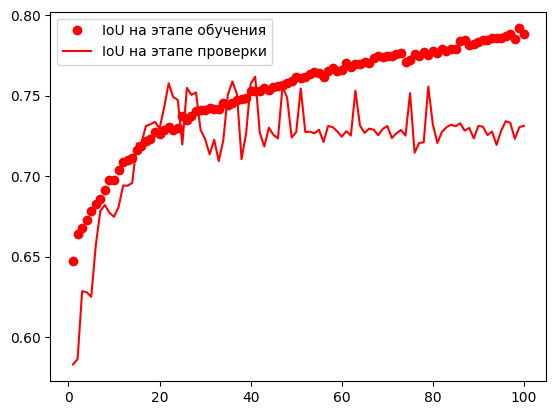

<Figure size 640x480 with 0 Axes>

In [ ]:
dense_2_mse = history.history["iou_metric"]
val_dense_2_mse = history.history["val_iou_metric"]

epochs_gf = range(1, len(dense_2_mse) + 1)

plt.plot(epochs_gf, dense_2_mse, "ro", label="IoU на этапе обучения")
plt.plot(epochs_gf, val_dense_2_mse, "r", label="IoU на этапе проверки")
plt.legend()
plt.figure()
plt.show()

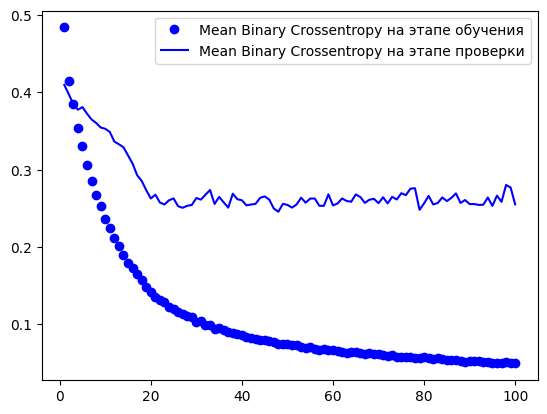

<Figure size 640x480 with 0 Axes>

In [ ]:
dense_2_mse = history.history["mean_binary_crossentropy_metric"]
val_dense_2_mse = history.history["val_mean_binary_crossentropy_metric"]

epochs_gf = range(1, len(dense_2_mse) + 1)

plt.plot(epochs_gf, dense_2_mse, "bo", label="Mean Binary Crossentropy на этапе обучения")
plt.plot(epochs_gf, val_dense_2_mse, "b", label="Mean Binary Crossentropy на этапе проверки")
plt.legend()
plt.figure()
plt.show()

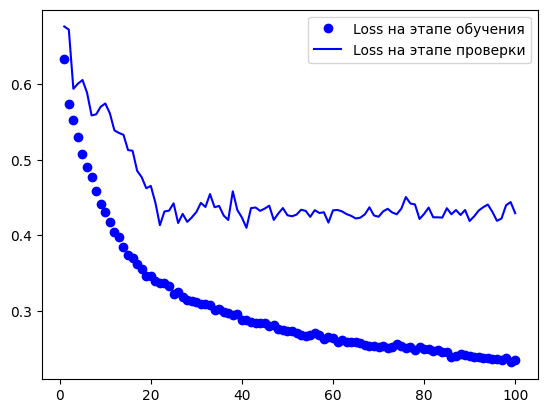

<Figure size 640x480 with 0 Axes>

In [ ]:
dense_2_mse = history.history["loss"]
val_dense_2_mse = history.history["val_loss"]

epochs_gf = range(1, len(dense_2_mse) + 1)

plt.plot(epochs_gf, dense_2_mse, "bo", label="Loss на этапе обучения")
plt.plot(epochs_gf, val_dense_2_mse, "b", label="Loss на этапе проверки")
plt.legend()
plt.figure()
plt.show()

2025-12-10 21:58:17.389820: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 372 bytes spill stores, 372 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


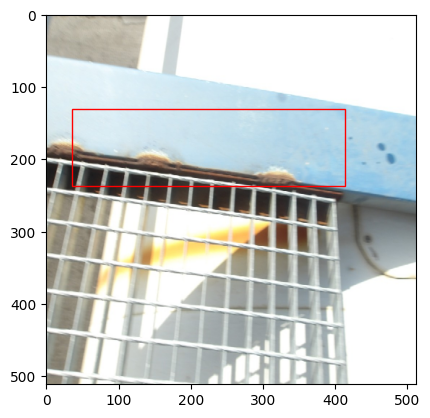

array([[0.07, 0.25, 0.74, 0.21, 0.95],
       [0.46, 0.45, 0.61, 0.41, 0.  ],
       [0.16, 0.31, 0.33, 0.6 , 0.  ],
       [0.56, 0.66, 0.15, 0.24, 0.  ],
       [0.32, 0.14, 0.09, 0.5 , 0.01]], dtype=float16)

In [ ]:
test_photo = np.ndarray(shape=(1, 512, 512, 3), dtype="float32")
test_photo[0] = images_ds[0]
test_boxes = model.predict(test_photo)
show_image(test_photo[0], test_boxes[0], alpha=0.65)
test_boxes[0].round(2)

In [ ]:
giou_metric(labels_ds, tf.zeros((num_samples, 5, 5)))

<tf.Tensor: shape=(), dtype=float32, numpy=0.44364410638809204>